# Process AIT Log Data Set v2.0

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

## Load Data

In [2]:
# santos
# scenario = "santos"

# sim_start = pd.Timestamp("2022-01-14 00:00")
# sim_end   = pd.Timestamp("2022-01-18 00:00")

# attack_start = pd.Timestamp("2022-01-17 11:15")
# attack_end   = pd.Timestamp("2022-01-17 11:59")

In [3]:
# fox
scenario = "fox"

sim_start = pd.Timestamp("2022-01-15 00:00")
sim_end   = pd.Timestamp("2022-01-20 00:00")

attack_start = pd.Timestamp("2022-01-18 11:59")
attack_end   = pd.Timestamp("2022-01-18 13:15")

In [4]:
dataset = "aitv2"
data_dir = f"../data/interim/{dataset}/{scenario}/flows_labeled"
df_all_sensors = pd.read_csv(f"{data_dir}/all_flows_labeled_unprocessed.csv")

## Trim to Simulation Period

In [5]:
# Convert start_time and end_time from seconds to datetime
df_all_sensors["start_time_dt"] = pd.to_datetime(df_all_sensors["start_time"], unit="s")
df_all_sensors["end_time_dt"] = pd.to_datetime(df_all_sensors["end_time"], unit="s")

print(f"Full dataset time range: {df_all_sensors['start_time_dt'].min()} to {df_all_sensors['end_time_dt'].max()}")
print("Total flows in combined dataset:", len(df_all_sensors))

Full dataset time range: 2022-01-14 10:45:58.631864071 to 2022-01-20 06:47:24.788824081
Total flows in combined dataset: 795824


In [6]:
# Trim to simulation period
df_sim = df_all_sensors[(df_all_sensors["start_time_dt"] >= sim_start) & (df_all_sensors["end_time_dt"] <= sim_end)]
print(f"Simulation period: {sim_start} to {sim_end}")
print(f"Total flows in simulation period: {len(df_sim)}")

Simulation period: 2022-01-15 00:00:00 to 2022-01-20 00:00:00
Total flows in simulation period: 727096


## Remove Duplicate Rows

### Load Netflow Data

In [7]:
netflows_path = f"../data/raw/{dataset}/{scenario}/netflows/all_netflows.csv"

df_netflows = pd.read_csv(netflows_path)
df_netflows_labels_counts = df_netflows["label"].value_counts()
netflows_labels = df_netflows["label"].unique()

print(netflows_labels)
print(df_netflows_labels_counts)
print()

['browsing/update' 'service_scan' 'online_cracking' 'benign_share' 'proxy'
 'host_discover_dmz' 'SSH' 'mail' 'HTTPS' 'DNS'
 'update/command on unassigned port' 'monitoring' 'HTTP(S) intra' 'HTTP'
 'host_discover_local' 'wpscan' 'dirb_scan' 'upload_rce_shell'
 'check_user_id' 'check_netstat_t' 'read_resolv' 'check_network_config'
 'check_ps_a' 'check_release' 'read_group' 'read_passwd' 'check_date'
 'list_web_dir' 'check_wp_config' 'dump_wp_users' 'read_profile'
 'dns_brute_force_start' 'HTTP(S) DMZ' 'broken flow - benign'
 'data exfiltration' 'mDNSv6' 'mDNS' 'bootp' 'NTP'
 'systemd-resolver (local)' 'benign DNS - attacker requesting updates'
 'benign DNS' 'OpenVPN' 'QUIC' 'STUN VoIP' 'NetBIOS']
label
benign DNS                                  79043
proxy                                       64434
HTTPS                                       34918
host_discover_local                         32788
browsing/update                             27876
benign_share                            

### Check Labeling

In [8]:
def get_observed_labels_and_counts(df):
    observed_labels = set()
    observed_labels_counts = {}
    for label in df["label"].unique():
        observed_labels.add(label)
        observed_labels_counts[label] = len(df[df["label"] == label])
    return observed_labels, observed_labels_counts

observed_labels, observed_labels_counts = get_observed_labels_and_counts(df_sim)

In [9]:
print("Unique labels observed across all sensors:")
print(list(observed_labels))

print("Labels in netflows but not observed:")
missing_labels = [label for label in netflows_labels if label not in observed_labels]
print(missing_labels)

Unique labels observed across all sensors:
['systemd-resolver (local)', 'benign', 'mail', 'bootp', 'check_release', 'check_user_id', 'check_ps_a', 'list_web_dir', 'service_scan', 'check_netstat_t', 'HTTP(S) intra', 'check_date', 'proxy', 'check_wp_config', 'OpenVPN', 'check_network_config', 'host_discover_local', 'dns_brute_force_start', 'read_resolv', 'dump_wp_users', 'read_passwd', 'SSH', 'upload_rce_shell', 'wpscan', 'HTTP(S) DMZ', 'dirb_scan', 'update/command on unassigned port', 'benign_share', 'data exfiltration', 'benign DNS', 'NTP', 'HTTPS', 'monitoring', 'HTTP', 'read_group', 'online_cracking', 'QUIC', 'benign DNS - attacker requesting updates', 'broken flow - benign', 'STUN VoIP', 'host_discover_dmz', 'read_profile', 'DNS', 'browsing/update']
Labels in netflows but not observed:
['mDNSv6', 'mDNS', 'NetBIOS']


In [10]:
for label in observed_labels:
    print(f"Observed number of flows with label '{label}': {observed_labels_counts[label]}")
    print(f"Number of flows with label '{label}' in netflows: {df_netflows_labels_counts.get(label, 0)}")
    print()

Observed number of flows with label 'systemd-resolver (local)': 532
Number of flows with label 'systemd-resolver (local)' in netflows: 366

Observed number of flows with label 'benign': 207002
Number of flows with label 'benign' in netflows: 0

Observed number of flows with label 'mail': 3618
Number of flows with label 'mail' in netflows: 2942

Observed number of flows with label 'bootp': 201
Number of flows with label 'bootp' in netflows: 1334

Observed number of flows with label 'check_release': 4
Number of flows with label 'check_release' in netflows: 2

Observed number of flows with label 'check_user_id': 4
Number of flows with label 'check_user_id' in netflows: 2

Observed number of flows with label 'check_ps_a': 4
Number of flows with label 'check_ps_a' in netflows: 2

Observed number of flows with label 'list_web_dir': 4
Number of flows with label 'list_web_dir' in netflows: 2

Observed number of flows with label 'service_scan': 24386
Number of flows with label 'service_scan' in

In [11]:
label = "data exfiltration"
print("Data exfiltration label counts:")
print(f"Observed: {observed_labels_counts.get(label, 0)}")
print(f"Netflows: {df_netflows_labels_counts.get(label, 0)}")

Data exfiltration label counts:
Observed: 44010
Netflows: 14668


### Remove Duplicates

In [12]:
# Remove duplicates by keeping only one entry per flow hash and sensor host
df_sim_no_duplicates = (
    df_sim
    .drop_duplicates(subset=["flow_hash", "sensor_host"])
    .drop(columns=["flow_hash", "start_hash", "end_hash"])
)

print("Original dataset shape:", df_sim.shape)
print("Final dataset shape:", df_sim_no_duplicates.shape)

Original dataset shape: (727096, 30)
Final dataset shape: (471234, 27)


In [13]:
observed_labels_no_duplicates, observed_labels_counts_no_duplicates = \
    get_observed_labels_and_counts(df_sim_no_duplicates)

for label in observed_labels_no_duplicates:
    print(f"Observed number of flows with label '{label}': {observed_labels_counts_no_duplicates[label]}")
    print(f"Number of flows with label '{label}' in netflows: {df_netflows_labels_counts.get(label, 0)}")
    print()

Observed number of flows with label 'systemd-resolver (local)': 366
Number of flows with label 'systemd-resolver (local)' in netflows: 366

Observed number of flows with label 'benign': 130658
Number of flows with label 'benign' in netflows: 0

Observed number of flows with label 'mail': 2952
Number of flows with label 'mail' in netflows: 2942

Observed number of flows with label 'bootp': 189
Number of flows with label 'bootp' in netflows: 1334

Observed number of flows with label 'check_release': 2
Number of flows with label 'check_release' in netflows: 2

Observed number of flows with label 'check_user_id': 2
Number of flows with label 'check_user_id' in netflows: 2

Observed number of flows with label 'check_ps_a': 2
Number of flows with label 'check_ps_a' in netflows: 2

Observed number of flows with label 'list_web_dir': 2
Number of flows with label 'list_web_dir' in netflows: 2

Observed number of flows with label 'service_scan': 13924
Number of flows with label 'service_scan' in

### Save Final Dataset

In [14]:
df_sim_no_duplicates.to_csv(f"{data_dir}/all_flows_labeled_sim.csv", index=False)
print("Combined dataset shape:", df_sim_no_duplicates.shape)
df_sim_no_duplicates.head()

Combined dataset shape: (471234, 27)


,flow_id,start_time,end_time,duration,src_ip,sport,dst_ip,dport,proto,service,...,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,ip_proto,label,sensor_host,start_time_dt,end_time_dt
63228,f1921,1.642205e+09,1.642205e+09,0.099298,10.35.35.206,60538,91.189.91.157,123,udp,ntp,...,1,76,1,76,-,17,NTP,intranet_server,2022-01-15 00:00:00.869369984,2022-01-15 00:00:00.968667984
63229,f14196,1.642205e+09,1.642205e+09,0.098276,192.168.128.4,60538,91.189.91.157,123,udp,ntp,...,1,76,1,76,-,17,NTP,inet_firewall,2022-01-15 00:00:00.870096922,2022-01-15 00:00:00.968372822
63230,f3334,1.642205e+09,1.642205e+09,0.053324,172.17.129.140,43702,10.35.33.111,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,cloud_share,2022-01-15 00:00:02.130912066,2022-01-15 00:00:02.184236050
63232,f5126,1.642205e+09,1.642205e+09,0.051889,172.17.129.140,43702,10.35.33.111,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,internal_share,2022-01-15 00:00:02.131725073,2022-01-15 00:00:02.183614016
63234,f3335,1.642205e+09,1.642205e+09,0.012432,172.17.129.140,43704,10.35.33.111,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,cloud_share,2022-01-15 00:00:02.226455927,2022-01-15 00:00:02.238888025


## Plotting

In [15]:
# From now on only use df
df = df_sim_no_duplicates.copy()

### Plotting Functions

In [1]:
def plot_event_raster(df_attack, order, scenario_name, attack=False, invert_y=True, save_plot=False, file_path=None):

    plt.figure(figsize=(14, 0.35 * len(order)))

    sample = df_attack.sample(
        min(len(df_attack), 5000),
        random_state=0
    ).sort_values("start_time_dt")

    label_to_idx = {lbl: i for i, lbl in enumerate(order)}

    ys = sample['label'].map(label_to_idx).astype(float)

    # jitter to reveal density
    ys += np.random.uniform(-0.15, 0.15, size=len(ys))

    # horizontal guides
    for y in label_to_idx.values():
        plt.axhline(y, color="lightgray", lw=0.5, zorder=0)

    plt.scatter(
        sample['start_time_dt'],  
        ys,
        s=2,
        alpha=0.5,
        rasterized=True
    )

    plt.yticks(list(label_to_idx.values()), list(label_to_idx.keys()))

    plt.grid(axis="x", linestyle=":", alpha=0.4)

    plt.xlabel("Time")
    plt.ylabel("Event Type")
    plt.title("{} MSA", pad=12)

    ax = plt.gca()

    if attack:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        plt.xticks(rotation=30)

    if invert_y:
        ax.invert_yaxis()

    plt.tight_layout()
    if save_plot:
        plt.savefig(file_path, dpi=300, bbox_inches='tight')
    plt.show()

### Plot Full Simulation Period

In [17]:
all_labels = list(netflows_labels)
all_labels.append("benign")
print("All labels (netflows + benign):", all_labels)

All labels (netflows + benign): ['browsing/update', 'service_scan', 'online_cracking', 'benign_share', 'proxy', 'host_discover_dmz', 'SSH', 'mail', 'HTTPS', 'DNS', 'update/command on unassigned port', 'monitoring', 'HTTP(S) intra', 'HTTP', 'host_discover_local', 'wpscan', 'dirb_scan', 'upload_rce_shell', 'check_user_id', 'check_netstat_t', 'read_resolv', 'check_network_config', 'check_ps_a', 'check_release', 'read_group', 'read_passwd', 'check_date', 'list_web_dir', 'check_wp_config', 'dump_wp_users', 'read_profile', 'dns_brute_force_start', 'HTTP(S) DMZ', 'broken flow - benign', 'data exfiltration', 'mDNSv6', 'mDNS', 'bootp', 'NTP', 'systemd-resolver (local)', 'benign DNS - attacker requesting updates', 'benign DNS', 'OpenVPN', 'QUIC', 'STUN VoIP', 'NetBIOS', 'benign']


In [18]:
phase_bounds_sim = (
    df[df['label'].isin(all_labels)]
    .groupby('label')['start_time_dt']
    .agg(['min', 'max'])
    .sort_values('min')
)

phase_bounds_sim

,min,max
label,,
NTP,2022-01-15 00:00:00.869369984,2022-01-19 23:59:59.055074930
benign_share,2022-01-15 00:00:02.130912066,2022-01-19 23:45:03.798696995
benign DNS,2022-01-15 00:00:03.113534927,2022-01-19 23:56:57.619887114
data exfiltration,2022-01-15 00:00:03.117595911,2022-01-17 09:04:47.678828955
benign,2022-01-15 00:00:14.004781961,2022-01-19 23:59:49.425873995
monitoring,2022-01-15 00:09:12.140852928,2022-01-19 23:39:09.491734982
browsing/update,2022-01-15 00:51:09.932920933,2022-01-19 23:06:25.648124933
systemd-resolver (local),2022-01-15 01:12:33.923666000,2022-01-18 13:14:51.059628010
benign DNS - attacker requesting updates,2022-01-15 01:12:33.924525023,2022-01-18 09:31:24.424940109


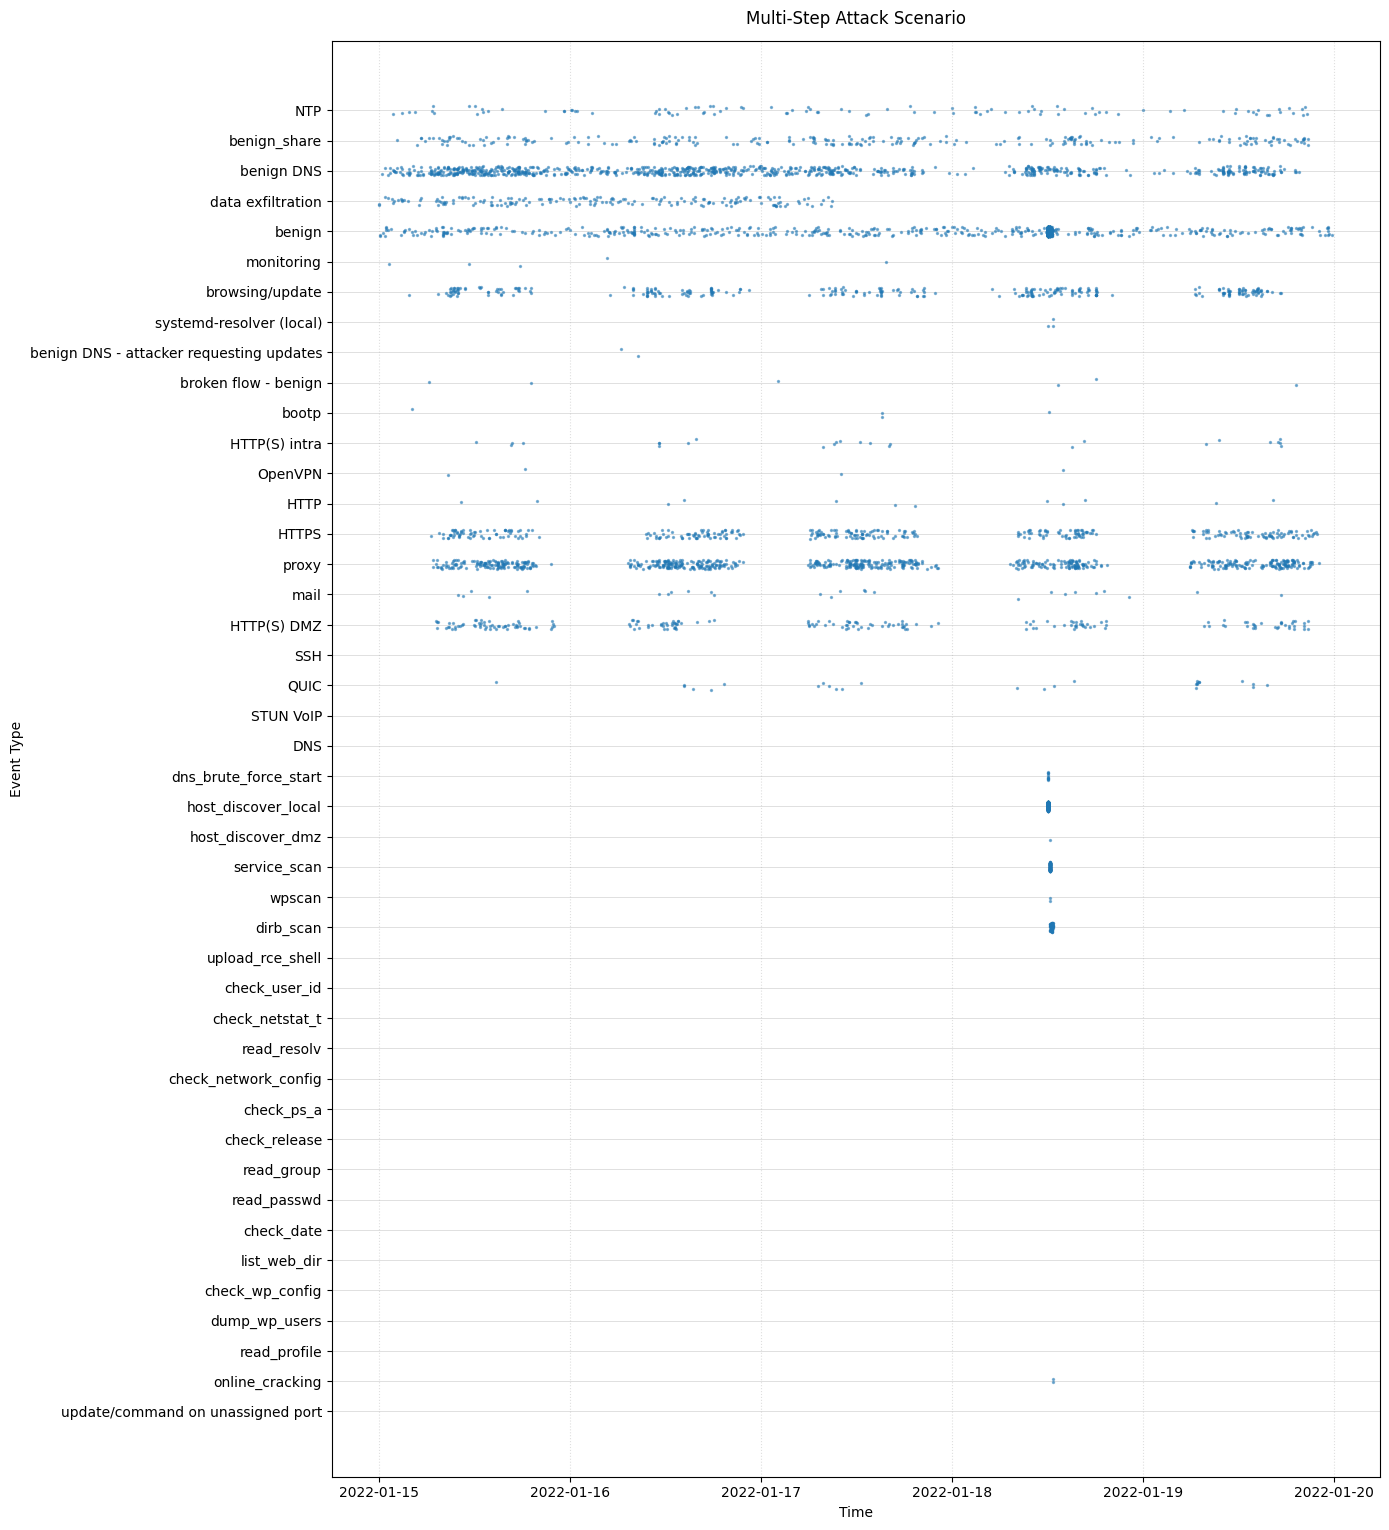

In [ ]:
order_sim = phase_bounds_sim.index.tolist()
plot_event_raster(df, order_sim, scenario)

### Plot Attack Period

In [20]:
print(f"Attack period - {scenario}:")
print(f"{attack_start} to {attack_end}")
    
df_attack_period = df[(df['start_time_dt'] >= attack_start) & (df['end_time_dt'] <= attack_end)]
print(f"Total attack flows in attack period: {len(df_attack_period)}")

Attack period - fox:
2022-01-18 11:59:00 to 2022-01-18 13:15:00
Total attack flows in attack period: 149173


In [21]:
phase_bounds_attack_period = (
    df_attack_period[df_attack_period['label'].isin(all_labels)]
    .groupby('label')['start_time_dt']
    .agg(['min', 'max'])
    .sort_values('min')
)

phase_bounds_attack_period

,min,max
label,,
systemd-resolver (local),2022-01-18 11:59:00.069930077,2022-01-18 13:14:51.059628010
benign,2022-01-18 11:59:01.340276003,2022-01-18 13:14:58.213723898
NTP,2022-01-18 11:59:01.346960068,2022-01-18 13:14:51.142399073
HTTPS,2022-01-18 11:59:10.918761015,2022-01-18 13:14:18.869208097
benign DNS,2022-01-18 11:59:11.631212950,2022-01-18 13:14:42.847486019
dns_brute_force_start,2022-01-18 11:59:14.508178949,2022-01-18 11:59:14.608710051
host_discover_local,2022-01-18 11:59:24.763206005,2022-01-18 12:02:40.928086042
HTTP(S) DMZ,2022-01-18 11:59:25.773236036,2022-01-18 12:48:42.411627054
proxy,2022-01-18 11:59:25.792012930,2022-01-18 12:48:42.432836056


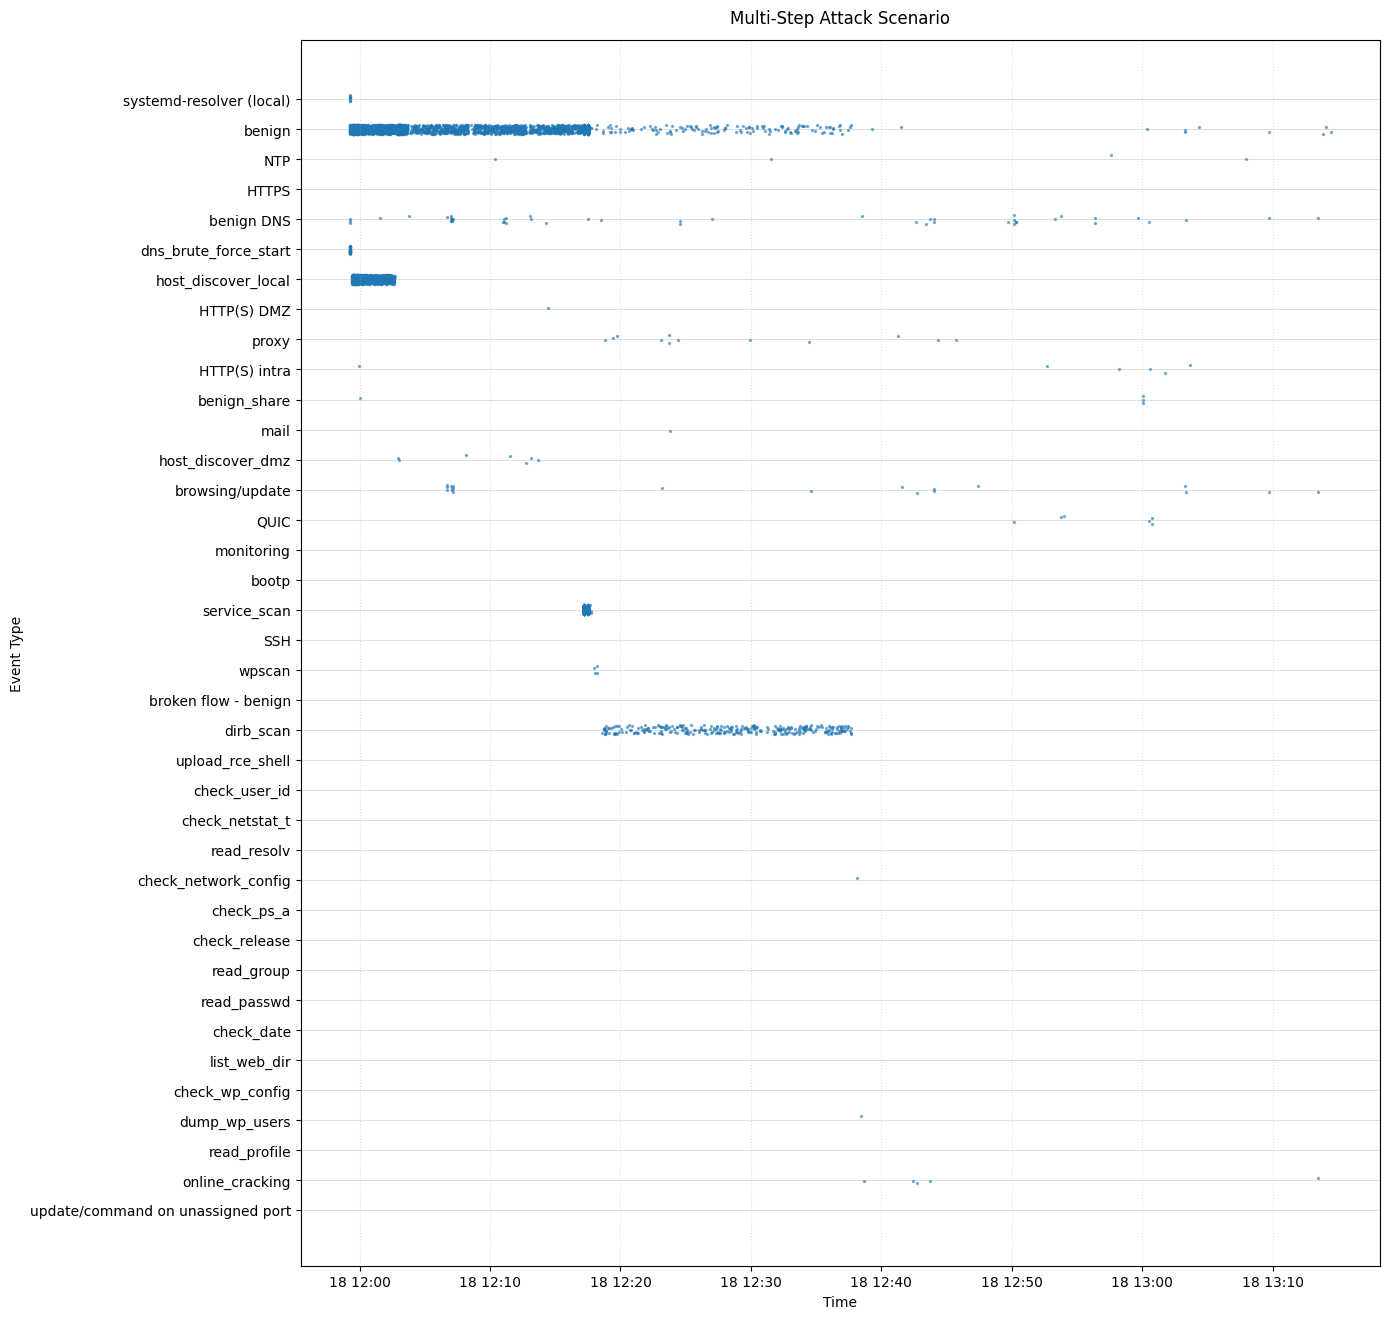

In [ ]:
order_attack_period = phase_bounds_attack_period.index.tolist()
plot_event_raster(df_attack_period, order_attack_period, scenario)

### Label Multi-Step Attack

**Multi-Step Attack Phases**

Scans / reconnaissance:
- The first step of the attack chain then consists of several scans of the network.

Webshell upload / exploitation:
- Attacker exploits the vulnerable plugin which allows him to upload a PHP webshell as a backdoor.
- The attacker proceeds to execute several commands to gather information about the host.

Password cracking: 
- The attacker then attempts to crack one of the hashed passwords using a list of common passwords.

Privilege escalation: 
- Subsequently after obtaining the password, the attacker uploads a fully interactive reverse shell and misuses the compromised user account to escalate their privileges to root level. 

Remote command execution: 
- The attacker then executes several commands of which some require root privileges, such as reading out the shadow file.

Data exfiltration:
- As a final step of the attack kill chain, the attacker runs the DNSteal tool that exfiltrates sensitive data from the file share located in the intranet zone.
- Important note: The authors decided to separate this step from the remaining attack vectors and instead start the exfiltration tool already at the beginning of the simulation.

Missing steps in Zeek flow data:
- Privilege escalation and remote command execution are not present in the Zeek flow data, which is likely due to the fact that these steps do not involve any network communication.

In [23]:
# From netflows labeling file:
benign_tcp_complete_labels = ["browsing/update", "benign_share", "mail", "monitoring", "HTTP(S) intra", "HTTP(S) DMZ", "SSH", "proxy", "HTTPS", "HTTP", "DNS", "update/command on unassigned port"]
benign_tcp_nocomplete_labels = ["broken flow - benign"]
benign_udp_labels = ["NTP", "bootp", "OpenVPN", "STUN VoIP", "NetBIOS", "QUIC", "mDNS", "mDNSv6", "GoogleDNS", "systemd-resolver (local)", "benign DNS", "benign DNS - attacker requesting updates"]

benign_labels = benign_tcp_complete_labels + benign_tcp_nocomplete_labels + benign_udp_labels + ["benign"]

In [24]:
# From netflows labeling file:

# foothold_labels = ["vpn_connect", "traceroute", "host_discover_local", "host_discover_dmz", "dns_brute_force_start", "service_scan", "wpscan", "dirb_scan", "upload_rce_shell", "host_recon_commands", "online_cracking", "run_cracking"]
# pwd_cracking_labels = ["Password cracking"]
# check_labels = ["check_df", "read_passwd", "check_id", "check_last", "read_resolv", "dump_wp_users", "check_who", "check_wp_config", "clear", "list_l", "check_netstat_l", "check_user_id", "check_uptime", "check_netstat_t", "read_group", "list_web_dir", "check_uname_r", "check_ps_a", "check_uname_a", "check_pwd", "check_network_config", "check_whoami", "list_home", "list_www", "check_meminfo", "check_netstat_nat", "check_date", "check_release", "read_profile"]

exfil = ['data exfiltration']
recon = ['dns_brute_force_start', 'host_discover_local', 'host_discover_dmz', 'service_scan', 'wpscan', 'dirb_scan']
exploit = ['upload_rce_shell', 'check_user_id', 'check_netstat_t', 'read_resolv', 'check_network_config', 'check_ps_a', 'check_release', 'read_group', 'read_passwd', 'check_date', 'list_web_dir', 'check_wp_config', 'dump_wp_users', 'read_profile']
cracking = ['online_cracking']

msa_labels = recon + exploit + cracking + exfil

In [25]:
# Sanity check
observed_labels = set(df_sim["label"].unique())
print("All labels in dataset:\n", observed_labels)
print("Benign labels:\n", set(benign_labels))
print("Multi-step attack labels:\n", set(msa_labels))
print()
print("Number of unique labels in observed data:", len(observed_labels))
print("Total number of unique labels in true categories:", len(benign_labels) + len(msa_labels)) 

for observed_label in observed_labels:
    if observed_label not in benign_labels and observed_label not in msa_labels:
        print(f"Label '{observed_label}' is in the dataset but not categorized as benign, multi-step attack, or exfiltration")

# assert(all_labels.issubset(set(benign_labels) | set(msa_labels))), "Some labels in the dataset are not categorized as benign, multi-step attack, or exfiltration"
# assert(len(all_labels) <= len(benign_labels) + len(msa_labels)), "There are more unique labels in the dataset than the total number of labels defined in the categories"

All labels in dataset:
 {'systemd-resolver (local)', 'benign', 'mail', 'bootp', 'check_release', 'check_user_id', 'check_ps_a', 'list_web_dir', 'service_scan', 'check_netstat_t', 'HTTP(S) intra', 'check_date', 'proxy', 'check_wp_config', 'OpenVPN', 'check_network_config', 'host_discover_local', 'dns_brute_force_start', 'read_resolv', 'dump_wp_users', 'read_passwd', 'SSH', 'upload_rce_shell', 'wpscan', 'HTTP(S) DMZ', 'dirb_scan', 'update/command on unassigned port', 'benign_share', 'data exfiltration', 'benign DNS', 'NTP', 'HTTPS', 'monitoring', 'HTTP', 'read_group', 'online_cracking', 'QUIC', 'benign DNS - attacker requesting updates', 'broken flow - benign', 'STUN VoIP', 'host_discover_dmz', 'read_profile', 'DNS', 'browsing/update'}
Benign labels:
 {'systemd-resolver (local)', 'benign', 'mail', 'bootp', 'GoogleDNS', 'mDNSv6', 'NetBIOS', 'HTTP(S) intra', 'proxy', 'OpenVPN', 'SSH', 'HTTP(S) DMZ', 'update/command on unassigned port', 'benign_share', 'benign DNS', 'NTP', 'HTTPS', 'monitor

In [26]:
df_msa = df_attack_period[df_attack_period["label"].isin(msa_labels)]
print(f"Total multi-step attack flows in true attack period: {len(df_msa)}")

Total multi-step attack flows in true attack period: 56532


In [27]:
obs_msa_labels, obs_msa_label_counts = \
    get_observed_labels_and_counts(df_msa)

for label in obs_msa_labels:
    print(f"Observed number of flows with msa label '{label}': {obs_msa_label_counts[label]}")
    print(f"Number of flows with msa label '{label}' in netflows: {df_netflows_labels_counts.get(label, 0)}")
    print()

Observed number of flows with msa label 'check_release': 2
Number of flows with msa label 'check_release' in netflows: 2

Observed number of flows with msa label 'check_user_id': 2
Number of flows with msa label 'check_user_id' in netflows: 2

Observed number of flows with msa label 'check_ps_a': 2
Number of flows with msa label 'check_ps_a' in netflows: 2

Observed number of flows with msa label 'list_web_dir': 2
Number of flows with msa label 'list_web_dir' in netflows: 2

Observed number of flows with msa label 'service_scan': 13924
Number of flows with msa label 'service_scan' in netflows: 13901

Observed number of flows with msa label 'check_netstat_t': 2
Number of flows with msa label 'check_netstat_t' in netflows: 2

Observed number of flows with msa label 'check_wp_config': 2
Number of flows with msa label 'check_wp_config' in netflows: 2

Observed number of flows with msa label 'check_date': 2
Number of flows with msa label 'check_date' in netflows: 2

Observed number of flows

In [28]:
phase_bounds_msa = (
    df_msa
    .groupby('label')['start_time_dt']
    .agg(['min', 'max'])
    .sort_values('min')
)

phase_bounds_msa

,min,max
label,,
dns_brute_force_start,2022-01-18 11:59:14.508178949,2022-01-18 11:59:14.608710051
host_discover_local,2022-01-18 11:59:24.763206005,2022-01-18 12:02:40.928086042
host_discover_dmz,2022-01-18 12:02:52.446352005,2022-01-18 12:14:50.528302908
service_scan,2022-01-18 12:17:14.234992027,2022-01-18 12:17:43.861294031
wpscan,2022-01-18 12:17:50.429045916,2022-01-18 12:18:13.388248920
dirb_scan,2022-01-18 12:18:30.335740089,2022-01-18 12:37:48.927057981
upload_rce_shell,2022-01-18 12:38:00.677339077,2022-01-18 12:38:00.677897930
check_user_id,2022-01-18 12:38:04.704194069,2022-01-18 12:38:04.704286098
check_netstat_t,2022-01-18 12:38:06.522208929,2022-01-18 12:38:06.522558928


In [29]:
out_dir = Path(f"../reports/{dataset}/msa_scenarios")
out_dir.mkdir(parents=True, exist_ok=True)
file_path = out_dir / f"{scenario}.png"

In [2]:
order_msa = phase_bounds_msa.index.tolist()
plot_event_raster(df_attack=df_msa, order=order_msa, scenario_name=scenario, attack=True, invert_y=False, save_plot=True, file_path = file_path)

NameError: name 'phase_bounds_msa' is not defined

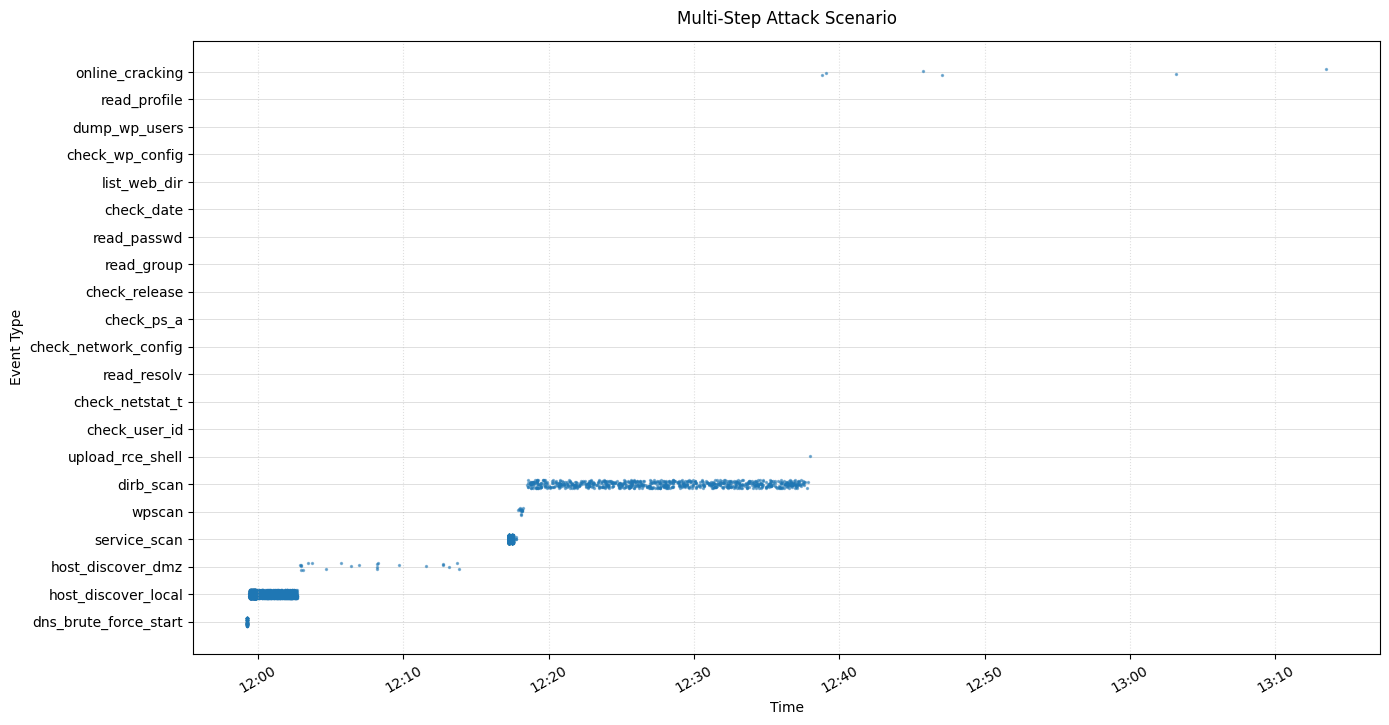

In [ ]:
phase_bounds_msa_no_exfil = (
    df_msa[df_msa['label'] != 'data exfiltration']
    .groupby('label')['start_time_dt']
    .agg(['min', 'max'])
    .sort_values('min')
)

order_msa_no_exfil = phase_bounds_msa_no_exfil.index.tolist()
plot_event_raster(df_attack=df_msa, order=order_msa_no_exfil, scenario_name=scenario, attack=True, invert_y=False)

In [32]:
def label_phase(label):
    if label in exfil:
        return 1
    if label in recon:
        return 2
    elif label in exploit:
        return 3
    elif label in cracking:
        return 4
    else: # benign or unknown
        return 0
    
# Reload the dataset to ensure we have the original labels before adding the phase column
df = pd.read_csv(f"{data_dir}/all_flows_labeled_sim.csv")

df["phase"] = df["label"].apply(label_phase)
label_counts = df["phase"].value_counts()
print("Phase distribution:")
print(label_counts)
df.to_csv(f"{data_dir}/all_flows_labeled.csv", index=False)

Phase distribution:
phase
0    400024
2     56443
1     14678
4        61
3        28
Name: count, dtype: int64


## Dataset Statistics

In [33]:
def label_stats(df, sensor_host, plot_bar=True):
    label_counts = df["label"].value_counts()
    print("Label Distribution for {}:".format(sensor_host))
    print(label_counts)

    if plot_bar:
        bar = label_counts.plot(kind="bar")
        bar.set_title("Label Distribution - {}".format(sensor_host))
        bar.set_yscale("log")
    print()

In [34]:
def dataset_stats(df, print_details=True):
    total_flows = len(df)
    unique_src_ips = df["src_ip"].nunique()
    unique_dst_ips = df["dst_ip"].nunique()
    unique_src_ports = df["sport"].nunique()
    unique_dst_ports = df["dport"].nunique()

    if print_details:
        print(f"Total Flows: {total_flows}")
        print(f"Unique Source IPs: {unique_src_ips}")
        print(f"Unique Destination IPs: {unique_dst_ips}")
        print(f"Unique Source Ports: {unique_src_ports}")
        print(f"Unique Destination Ports: {unique_dst_ports}")

    return {
        "total_flows": total_flows,
        "unique_src_ips": unique_src_ips,
        "unique_dst_ips": unique_dst_ips,
        "unique_src_ports": unique_src_ports,
        "unique_dst_ports": unique_dst_ports,
    }

In [35]:
def dataset_stats_detailed(df, print_details=True):
    src_ips = df["src_ip"].value_counts()
    dst_ips = df["dst_ip"].value_counts()
    src_ports = df["sport"].value_counts()
    dst_ports = df["dport"].value_counts()

    if print_details:
        print("Total Flows:", len(df))

        print("\n --- IP distribution ---")
        print(f"\nSource IPs ({len(src_ips)}):")
        print(src_ips)
        print(f"\nDestination IPs ({len(dst_ips)}):")
        print(dst_ips)

        print("\n --- Port distribution ---")
        print(f"Source Ports ({len(src_ports)}):")
        print(src_ports)
        print(f"\nDestination Ports ({len(dst_ports)}):")
        print(dst_ports)

    return src_ips, dst_ips, src_ports, dst_ports

Label Distribution for All Sensors:
label
host_discover_local      32788
service_scan             13924
dirb_scan                 8259
dns_brute_force_start     1192
host_discover_dmz          152
wpscan                     128
online_cracking             61
check_user_id                2
upload_rce_shell             2
read_resolv                  2
check_network_config         2
check_ps_a                   2
check_netstat_t              2
check_release                2
read_group                   2
check_date                   2
read_passwd                  2
list_web_dir                 2
check_wp_config              2
dump_wp_users                2
read_profile                 2
Name: count, dtype: int64



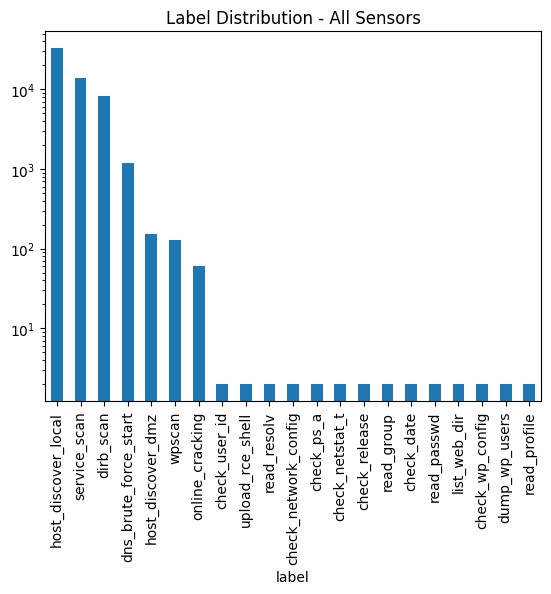

In [36]:
label_stats(df_msa, "All Sensors")

In [37]:
# Sim dataset stats
dataset_stats(df)

Total Flows: 471234
Unique Source IPs: 121
Unique Destination IPs: 27721
Unique Source Ports: 48259
Unique Destination Ports: 2426


{'total_flows': 471234,
 'unique_src_ips': 121,
 'unique_dst_ips': 27721,
 'unique_src_ports': 48259,
 'unique_dst_ports': 2426}

In [38]:
# Attack flows stats
dataset_stats(df_msa)

Total Flows: 56532
Unique Source IPs: 6
Unique Destination IPs: 8207
Unique Source Ports: 13627
Unique Destination Ports: 1413


{'total_flows': 56532,
 'unique_src_ips': 6,
 'unique_dst_ips': 8207,
 'unique_src_ports': 13627,
 'unique_dst_ports': 1413}

In [39]:
dataset_stats_detailed(df_msa)

Total Flows: 56532

 --- IP distribution ---

Source IPs (6):
src_ip
172.17.130.196     52390
192.168.130.77      4128
192.168.128.4          9
192.168.128.195        3
192.168.130.110        1
10.35.35.206           1
Name: count, dtype: int64

Destination IPs (8207):
dst_ip
10.35.35.206       10716
172.17.130.37       2846
192.168.128.4       2649
10.35.33.111        2488
172.17.129.140      2393
                   ...  
10.35.33.116           2
172.17.128.63          1
10.35.32.1             1
151.101.14.109         1
192.168.255.254        1
Name: count, Length: 8207, dtype: int64

 --- Port distribution ---
Source Ports (13627):
sport
59174    17
59510    16
59944    16
57950    15
52666    15
         ..
42324     1
45976     1
49212     1
54694     1
39356     1
Name: count, Length: 13627, dtype: int64

Destination Ports (1413):
dport
443      25052
80       16543
587         45
993         21
25          20
         ...  
40000        7
53535        7
60123        6
823        

(src_ip
 172.17.130.196     52390
 192.168.130.77      4128
 192.168.128.4          9
 192.168.128.195        3
 192.168.130.110        1
 10.35.35.206           1
 Name: count, dtype: int64,
 dst_ip
 10.35.35.206       10716
 172.17.130.37       2846
 192.168.128.4       2649
 10.35.33.111        2488
 172.17.129.140      2393
                    ...  
 10.35.33.116           2
 172.17.128.63          1
 10.35.32.1             1
 151.101.14.109         1
 192.168.255.254        1
 Name: count, Length: 8207, dtype: int64,
 sport
 59174    17
 59510    16
 59944    16
 57950    15
 52666    15
          ..
 42324     1
 45976     1
 49212     1
 54694     1
 39356     1
 Name: count, Length: 13627, dtype: int64,
 dport
 443      25052
 80       16543
 587         45
 993         21
 25          20
          ...  
 40000        7
 53535        7
 60123        6
 823          6
 1212         6
 Name: count, Length: 1413, dtype: int64)